In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')
small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str
    
graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'."""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['income_tax', 'real_estate_tax', 'llm']:
    """
    주어진 state에서 쿼리를 기반으로 적절한 경로를 결정합니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        Literal['income_tax', 'real_estate_tax', 'llm']: 쿼리에 따라 선택된 경로를 반환합니다.
    """
    query = state['query']
    router_chain = router_prompt | structured_router_llm 
    route = router_chain.invoke({'query': query})

    return route.target

In [5]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState) -> AgentState:
    """
    주어진 state에서 쿼리를 LLM에 전달하여 응답을 얻습니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'answer' 키를 포함하는 새로운 state를 반환합니다.
    """
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

In [7]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm'
    }
)
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [8]:
graph = graph_builder.compile()

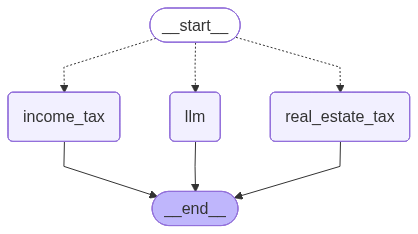

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

context == [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호의 금액을 12로 나눈 금액에 근속연수를 곱한 

{'query': '소득세란 무엇인가요?',
 'context': [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호

In [11]:
initial_state = {
    'query': '집 15억은 세금을 얼마나 내나요?'
}

graph.invoke(initial_state)

context = {'query': '오늘 날짜:(2026-04-19)의 주택에 대한 종합부동산세 계산시 공정시장가액비율은 몇 %인가요?', 'follow_up_questions': None, 'answer': 'For 2026, the public market value rate for calculating the property tax on housing is 60%. This rate applies to both property tax and comprehensive real estate tax. The rate was set at 60% starting in 2022 and is expected to revert to 80% in 2023.', 'images': ['https://cloudfront-ap-northeast-1.images.arcpublishing.com/chosunbiz/VCEXJ2Y4TRFWRGPJQSOELDWO6I.jpg', 'https://lookaside.fbsbx.com/lookaside/crawler/threads/DV3Nb1wGhnW/1/image.jpg', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMjU1/MDAxNzQxMjA5NzE0MTI3.yjvDGrS5xiH4fyDyePIh2e2b3MPgLCUEHcVtXXnSJ7cg.75H1A46b_weyUYG1zwwo30qQid4SRPppJJMwTsZ5ObIg.PNG/image.png?type=w800', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMzMg/MDAxNzQxMjA5NjU1NDcy.-9-c3YhVkE1_LQSZuoTeOlWwtBJaJZ7Zr8QOkpiVTbUg.wpdkmuG8YVq9og_7SSmGzmguM_R6IkDR2Eb-WZrc98gg.PNG/image.png?type=w800', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDRfMj

{'query': '집 15억은 세금을 얼마나 내나요?',
 'answer': '주어진 정보만으로는 **실제 세액은 “누구인지(1세대 1주택자 / 일반 개인 / 법인)”와 “주택 수”**에 따라 달라집니다.  \n또한 제공된 문서 기준으로는 **개인에 대한 주택분 종부세 세율은 “2주택 이하”와 “3주택 이상”**으로 나뉩니다.\n\n다만 질문 내용상 이미 과세표준이 정리되어 있으므로, 그 기준으로 **종합부동산세액(주택분)**을 계산하면 다음과 같습니다.\n\n---\n\n## 1) 1세대 1주택자\n- 과세표준: **1억 8천만원**\n- 주택 수: **1주택**이므로 **2주택 이하 세율** 적용\n- 세율 구간: **3억원 이하 → 1천분의 5**\n\n계산:\n- 1억 8천만원 × 0.5% = **90만원**\n\n**→ 종부세액: 90만원**\n\n---\n\n## 2) 일반 개인\n- 과세표준: **3억 6천만원**\n- 주택 수가 명확하지 않으나,  \n  - **2주택 이하**면 해당 세율표 적용\n  - **3주택 이상**이어도 3억 초과 6억 이하 구간까지는 세율이 동일\n\n세율 구간:\n- **3억 초과 6억 이하 → 150만원 + (3억원 초과금액의 1천분의 7)**\n\n계산:\n- 3억 6천만원 - 3억원 = 6천만원\n- 6천만원 × 0.7% = 42만원\n- 150만원 + 42만원 = **192만원**\n\n**→ 종부세액: 192만원**\n\n---\n\n## 3) 법인 또는 법인으로 보는 단체\n- 과세표준: **5억 4천만원**\n\n다만, 제공 문서에는 **법인에 대한 별도 세율표 내용이 완전하게 제시되어 있지 않아**,  \n정확한 **법인 종부세액**은 이 문서만으로 확정 계산하기 어렵습니다.\n\n그래서 **문서상 확정 가능한 개인 기준**으로만 보면:\n- **1세대 1주택자: 90만원**\n- **일반 개인: 192만원**\n\n---\n\n## 질문 “15억 집은 세금을 얼마나 내나요?”에 대한 답\n보유자 유

In [12]:
initial_state = {'query': '떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

{'query': '떡볶이는 어디가 맛있나요?',
 'answer': '떡볶이는 **취향 차이**가 좀 큰 편이라, “어디가 최고”라기보다 **어떤 스타일을 좋아하느냐**가 중요해요.\n\n### 많이들 찾는 스타일별 추천\n- **매운 떡볶이**: 엽기떡볶이, 신전떡볶이  \n  - 자극적이고 매운맛 좋아하면 잘 맞아요.\n- **국물 떡볶이**: 죠스떡볶이, 청년다방  \n  - 국물 넉넉하고 분식 느낌 좋아하면 괜찮아요.\n- **달달한 옛날 스타일**: 동네 분식집, 시장 떡볶이  \n  - 추억의 맛, 단짠한 스타일을 좋아하면 좋아요.\n- **로제/퓨전 떡볶이**: 배떡, 청년다방 일부 메뉴  \n  - 크리미하고 부드러운 맛 선호하면 추천해요.\n\n### 고를 때 팁\n- **매운 거 잘 못 먹으면**: 신전은 생각보다 매울 수 있어요.\n- **양 많고 자극적인 맛**: 엽떡\n- **분식 느낌/무난한 맛**: 죠스떡볶이\n- **특별한 맛**: 로제 떡볶이\n\n원하시면 제가  \n1) **매운맛 기준**,  \n2) **프랜차이즈 기준**,  \n3) **지역 맛집 찾는 법**  \n중 하나로 더 딱 맞게 추천해드릴게요.'}